In [1]:
import matplotlib.pyplot as plt
import numpy as np

from helpers import load_trail
import sys
sys.path.append('..')
from utils.functions import get_hv_max

In [2]:
def wrap_label(label, max_width=40): 
    if len(label) <= max_width:
        return label
    
    lines = []
    words = label.split(' ')
    current_line = ""
    
    for word in words:

        test_line = current_line + " " + word if current_line else word
        if len(test_line) <= max_width:
            current_line = test_line
        else:

            if len(current_line) > 0:
                lines.append(current_line.strip())
            if len(word) > max_width:

                while len(word) > max_width:
                    lines.append(word[:max_width])
                    word = word[max_width:]
                if word: 
                    lines.append(word)
                current_line = ""
            else:
                current_line = word 
    
    if current_line:
        lines.append(current_line)
    
    return '\n'.join(lines)

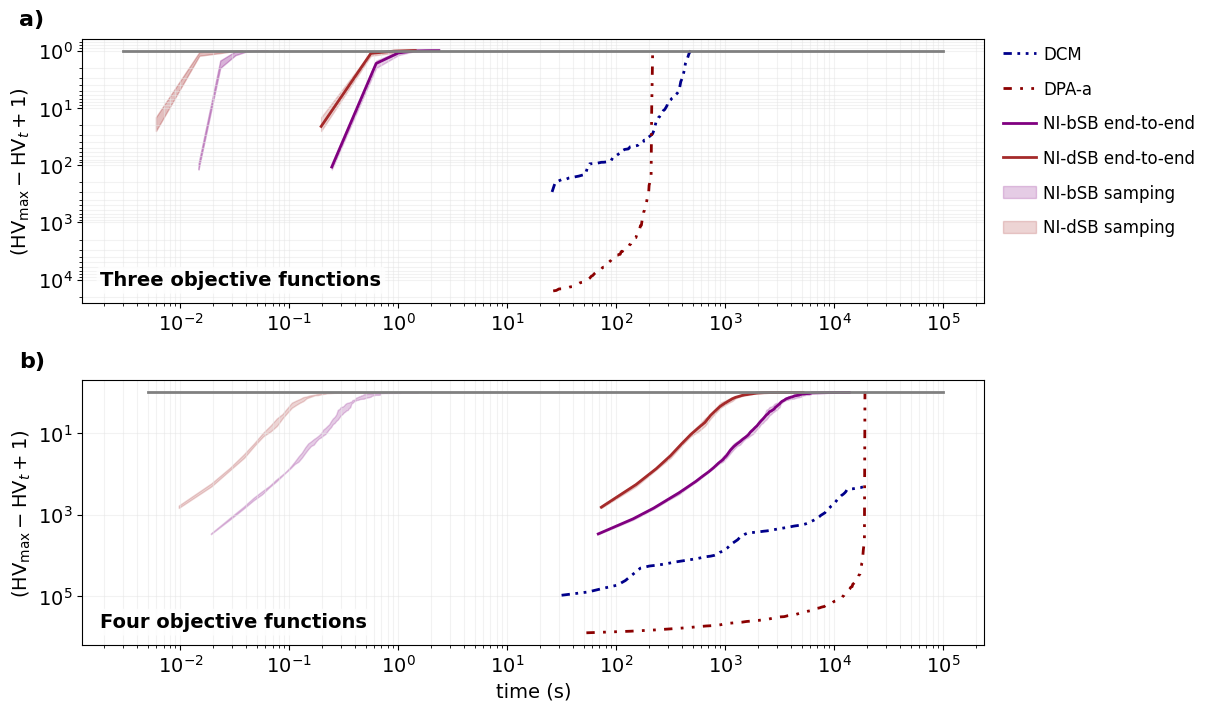

In [ ]:
# =============================================================================
# 1. Global Style & Font Configuration
# =============================================================================
set_basic_font = 14
plt.rcParams.update({
    "font.size": set_basic_font,
    "axes.labelsize": set_basic_font,
    "axes.titlesize": set_basic_font,
    "legend.fontsize": set_basic_font,
    "xtick.labelsize": set_basic_font,
    "ytick.labelsize": set_basic_font,
    "lines.linewidth": 2,
    'figure.constrained_layout.use': True
})

# =============================================================================
# 2. Figure & Grid Setup
# =============================================================================
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[12, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

# =============================================================================
# 3. Main Plotting Loop (3 vs 4 Objectives)
# =============================================================================
for idx, num_objectives in enumerate([3, 4]):
    ax = ax1 if idx == 0 else ax2
    hv_max = get_hv_max(num_objectives)
    
    # -------------------------------------------------------------------------
    # 3.1 DCM & DPA-a
    # -------------------------------------------------------------------------
    dcm_fname = f'plotdata_{num_objectives}obj_dcm.npz'
    dpa_fname = f'plotdata_{num_objectives}obj_dpa-a.npz'
    
    for fname, lbl, ls in [
        (dcm_fname, 'DCM',   (0, (3, 2, 1, 2, 1, 2))),
        (dpa_fname, 'DPA-a', (0, (3, 3, 1, 3, 1, 3)))
    ]:
        data = dict(np.load(f'./data_QA/s43588-025-00873-y_plotdata/{fname}'))
        ax.plot(data['x'], data['y'], linestyle=ls, color=str(data['color']), label=lbl)

    # -------------------------------------------------------------------------
    # 3.2 NI-bSB & NI-dSB (ETE & Sampling)
    # -------------------------------------------------------------------------
    # Load ETE data
    t_b, y_b, y_b_min, y_b_max = load_trail(str(num_objectives), 'b', category='ETE', path='./raw_data/')
    t_d, y_d, y_d_min, y_d_max = load_trail(str(num_objectives), 'd', category='ETE', path='./raw_data/')
    
    # Load Sampling data
    t_b_s, y_b_s, y_b_min_s, y_b_max_s = load_trail(str(num_objectives), 'b', category='sample', path='./raw_data/')
    t_d_s, y_d_s, y_d_min_s, y_d_max_s = load_trail(str(num_objectives), 'd', category='sample', path='./raw_data/')
    
    if num_objectives == 3:
        # ETE curves (no labels)
        ax.fill_between(t_b, y_b_min, y_b_max, color='purple', alpha=0.2)
        ax.plot(t_b, y_b, color='purple')
        ax.fill_between(t_d, y_d_min, y_d_max, color='brown', alpha=0.2)
        ax.plot(t_d, y_d, color='brown')
        # Sampling curves (no labels)
        ax.fill_between(t_b_s, y_b_min_s, y_b_max_s, color='purple', alpha=0.3)
        # ax.plot(t_b_s, y_b_s, color='purple', linestyle=':', alpha=0.8)
        ax.fill_between(t_d_s, y_d_min_s, y_d_max_s, color='brown', alpha=0.3)
        # ax.plot(t_d_s, y_d_s, color='brown', linestyle=':', alpha=0.8)

    else:  # num_objectives == 4
        # ETE curves (with labels)
        ax.fill_between(t_b, y_b_min, y_b_max, alpha=0.2, color='purple')
        ax.plot(t_b, y_b, label=r'NI-bSB end-to-end', color='purple')
        ax.fill_between(t_d, y_d_min, y_d_max, alpha=0.2, color='brown')
        ax.plot(t_d, y_d, label=r'NI-dSB end-to-end', color='brown')        
        # Sampling curves (with labels)
        ax.fill_between(t_b_s, y_b_min_s, y_b_max_s, color='purple', alpha=0.2,label=r'NI-bSB samping')
        # ax.plot(t_b_s, y_b_s, label=r'NI-bSB samping', color='purple', linestyle=':', alpha=0.8)
        ax.fill_between(t_d_s, y_d_min_s, y_d_max_s, color='brown', alpha=0.2,label=r'NI-dSB samping')
        # ax.plot(t_d_s, y_d_s, label=r'NI-dSB samping', color='brown', linestyle=':', alpha=0.8)


    # -------------------------------------------------------------------------
    # 3.3 Axis Styling & Reference Line
    # -------------------------------------------------------------------------
    x_start = 0.003 if num_objectives == 3 else 0.005
    ax.plot([x_start, 1e5], [1, 1], '-', color=[0.5, 0.5, 0.5])
    
    ax.loglog()
    ax.grid(which='both', axis='both', color=[0.9, 0.9, 0.9], alpha=0.5)
    ax.invert_yaxis()
    
    # Title box (bottom-left)
    title_text = "Three objective functions" if idx == 0 else "Four objective functions"
    ax.text(0.02, 0.05, title_text, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# =============================================================================
# 4. Panel Labels
# =============================================================================
ax1.text(-0.07, 1.05, 'a)', transform=ax1.transAxes, fontweight='bold', fontsize=16)
ax2.text(-0.07, 1.05, 'b)', transform=ax2.transAxes, fontweight='bold', fontsize=16)

# =============================================================================
# 5. Unified Legend
# =============================================================================
# Collect unique handles/labels from both subplots
handles, labels = [], []
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)

# Create dedicated axis for legend
ax_legend = fig.add_subplot(gs[:, 1])
ax_legend.axis('off')

# Apply wrapping & plot legend
wrapped_labels = [wrap_label(l) for l in labels]

ax_legend.legend(
    handles, wrapped_labels,
    loc='upper center',
    frameon=False,
    fontsize=12,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=1,
    ncol=1,
    borderaxespad=0.0,
)

# =============================================================================
# 6. Axis Labels & Export
# =============================================================================
y_label = r'$(\mathrm{HV}_{\mathrm{max}} - \mathrm{HV}_t + 1)$'
ax1.set_ylabel(y_label)
ax2.set_ylabel(y_label)
ax2.set_xlabel(r'time (s)')

# fig.savefig('Fig2.pdf', bbox_inches='tight', dpi=300)